In [1]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)


# 11 - 自动特征分析报告（订单口径 + 金额口径）

本示例演示 `auto_feature_analysis_report` 的两个新增能力：

1. 通过 `margins=True` 在每个变量分箱表末尾显示合计行；
2. 传入 `amount` 字段后，在 Excel 中并排展示**订单口径**（左）和**金额口径**（右）分箱表，中间空一列。


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from hscredit import init_setting
from hscredit.report.feature_report import auto_feature_analysis_report

init_setting()


In [3]:
# 读取示例数据（标签沿用之前样例：FPD15）
df = pd.read_excel('hscredit.xlsx')

# loan_date 是 Excel 序列日期，转换为 datetime
df['loan_date'] = pd.to_datetime(df['loan_date'], unit='D')

# 构造金额字段（可理解为放款金额/余额口径）
df['loan_amount_demo'] = df['loan_amt_sum_12m'].fillna(0)

print(df.shape)
print('目标坏样本率(FPD15):', round(df['FPD15'].mean(), 4))


(12448, 86)
目标坏样本率(FPD15): 0.0664


In [ ]:
# 选择部分特征做演示
features = [
    'bj_qy24',
    'mobtech80',
    'loan_behavior_score',
    'network_loan_credit_line',
    'lender_inquiry_count_3m',
]

feature_map = {
    'bj_qy24': '百融变量-bj_qy24',
    'mobtech80': '同盾变量-mobtech80',
    'loan_behavior_score': '借贷行为分',
    'network_loan_credit_line': '网贷授信额度',
    'lender_inquiry_count_3m': '近3个月机构查询次数',
}

bin_params = {
    'method': 'mdlp',
    'max_n_bins': 5,
    'min_bin_size': 0.01,
    'return_cols': ['坏样本数', '坏样本率', '分档WOE值', '分档IV值', '指标IV值', 'LIFT值'],
}


100%|██████████| 5/5 [00:09<00:00,  1.96s/it, feature=近3个月机构查询次数]   ]


报告已生成: feature_analysis_report_demo.xlsx


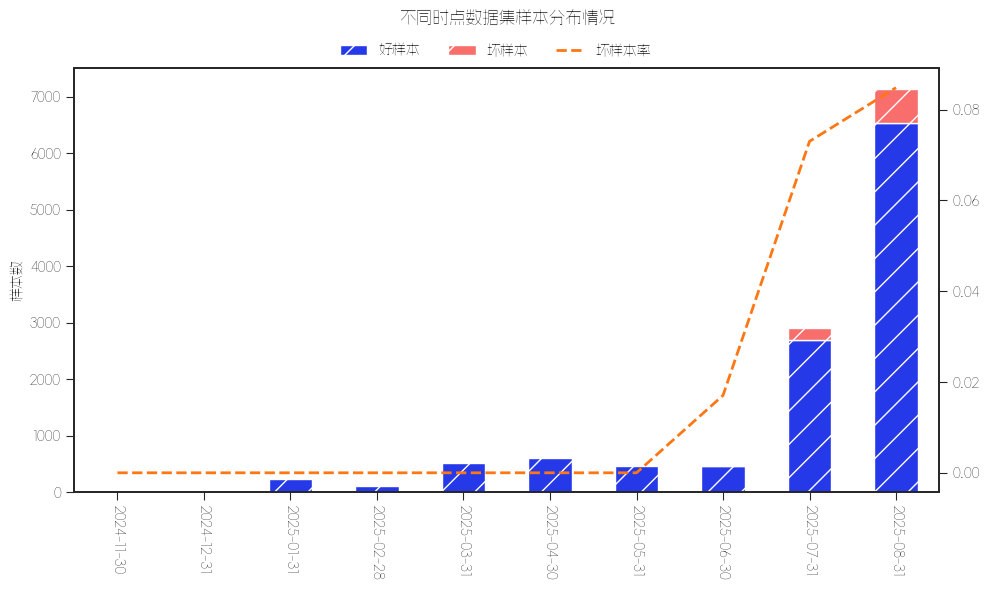

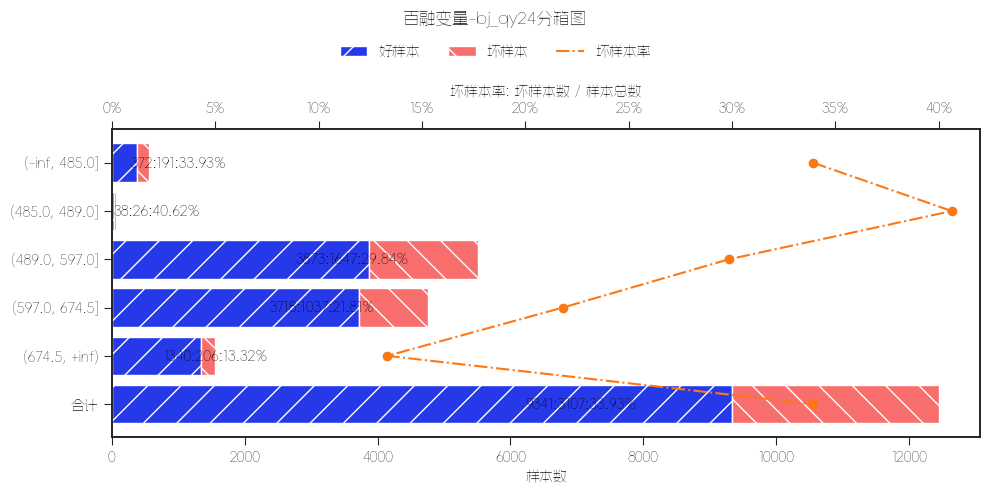

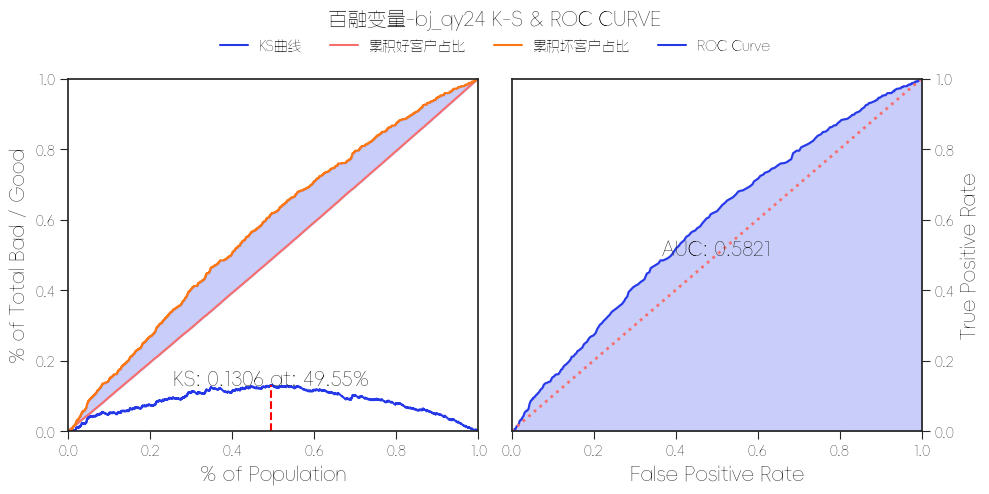

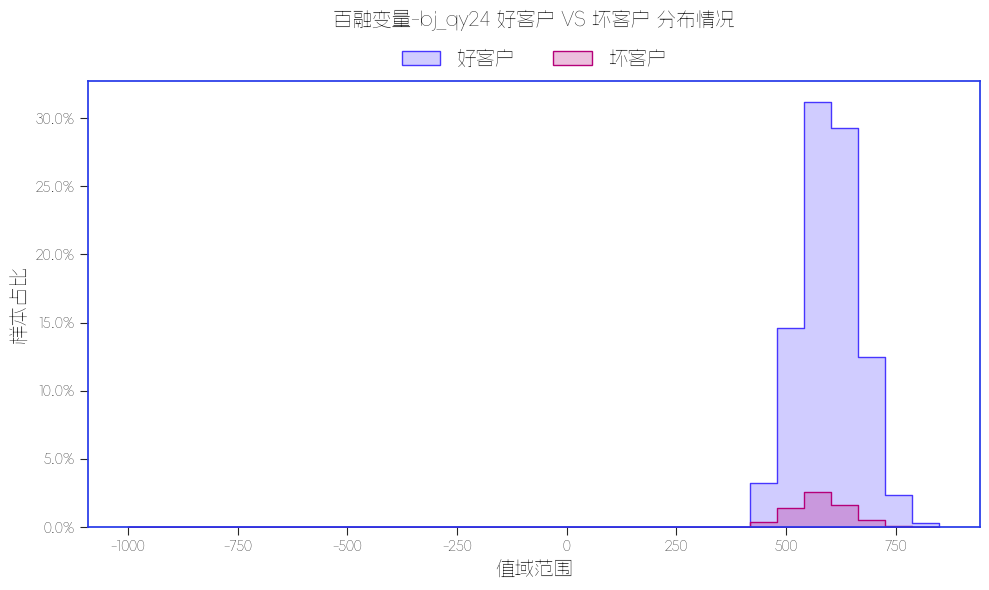

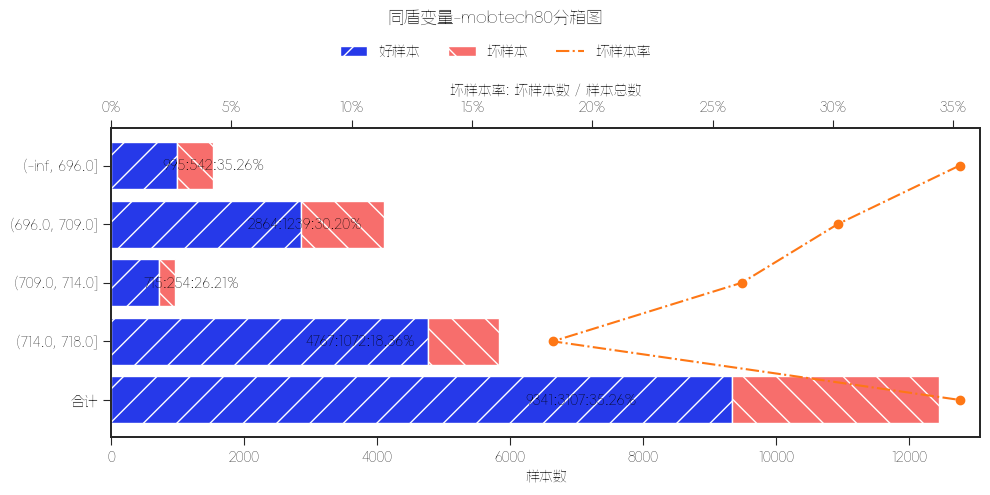

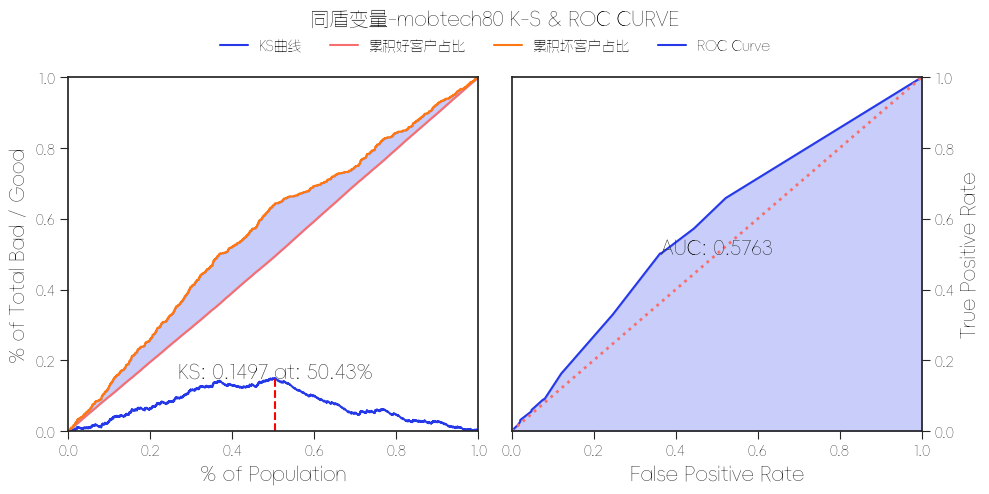

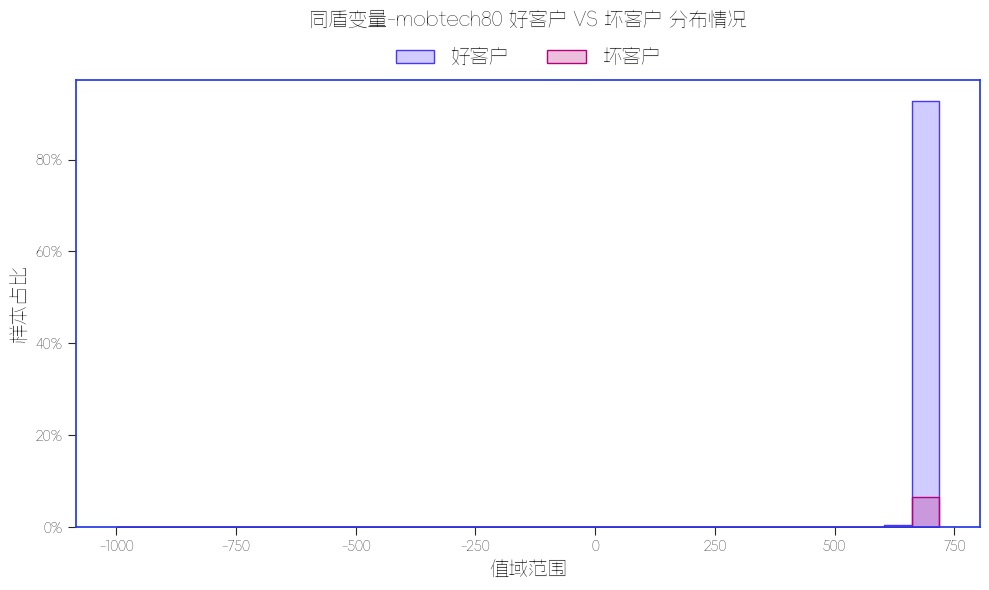

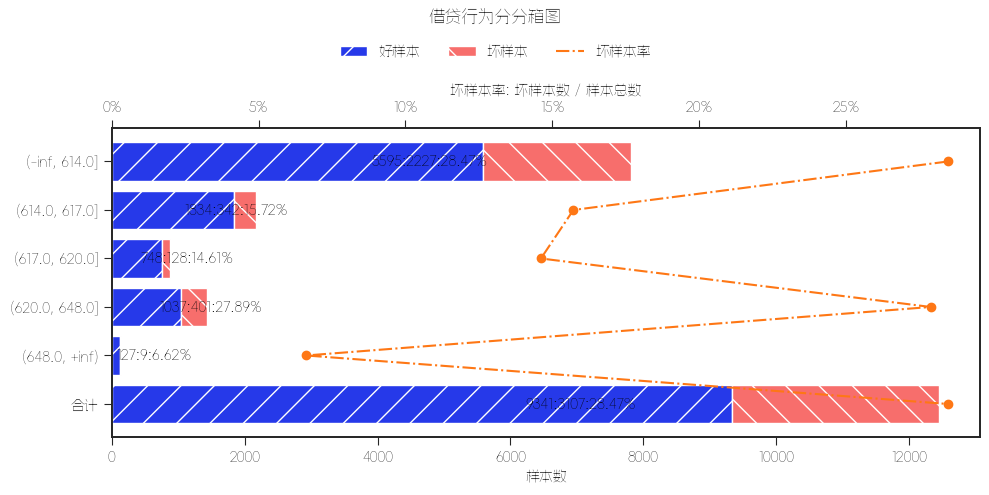

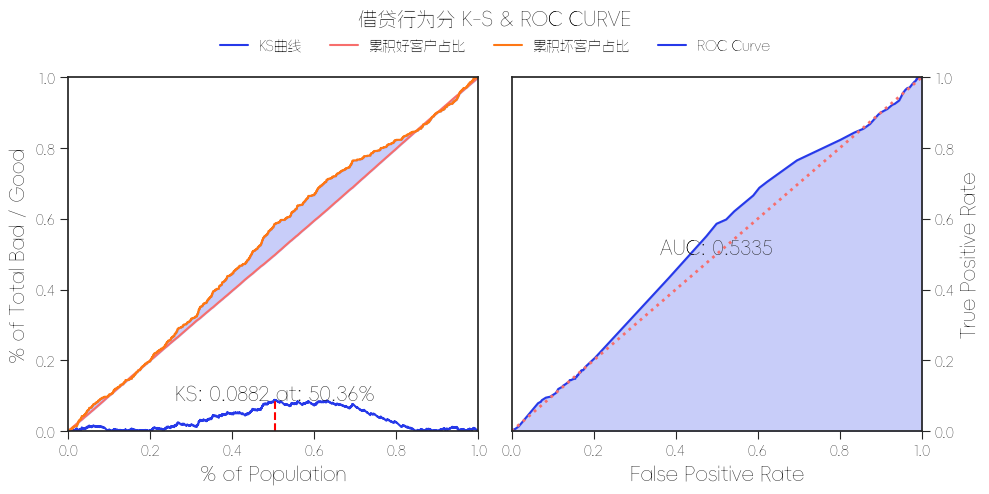

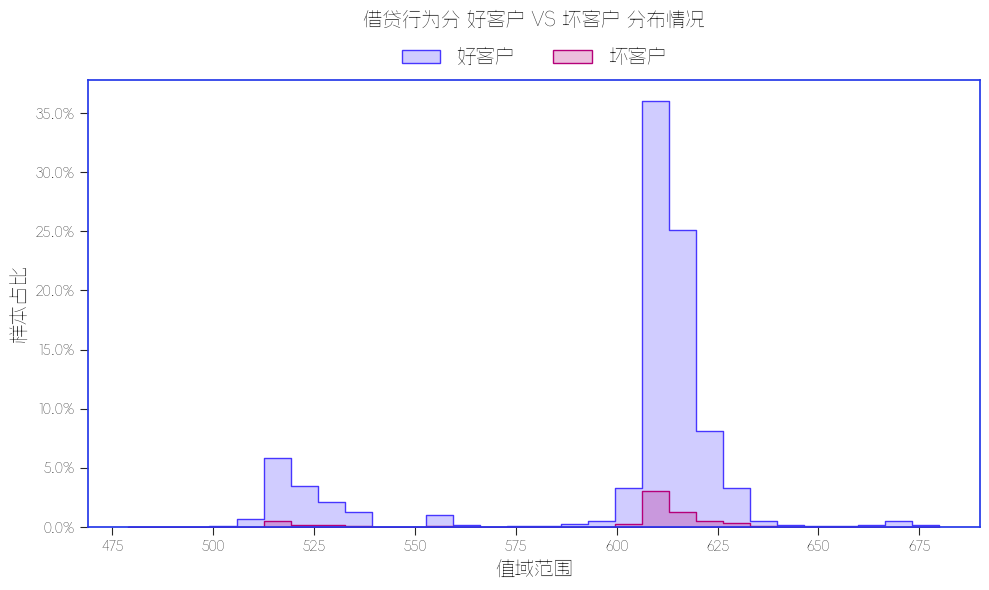

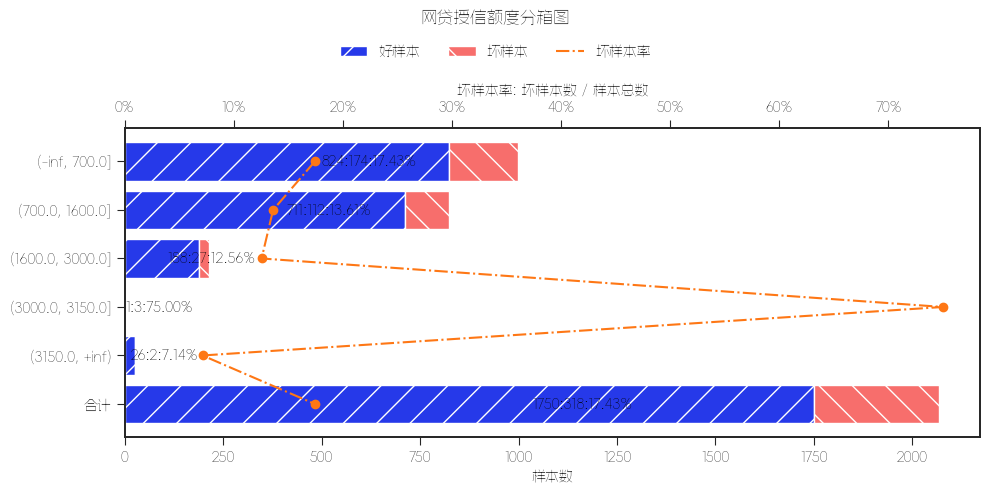

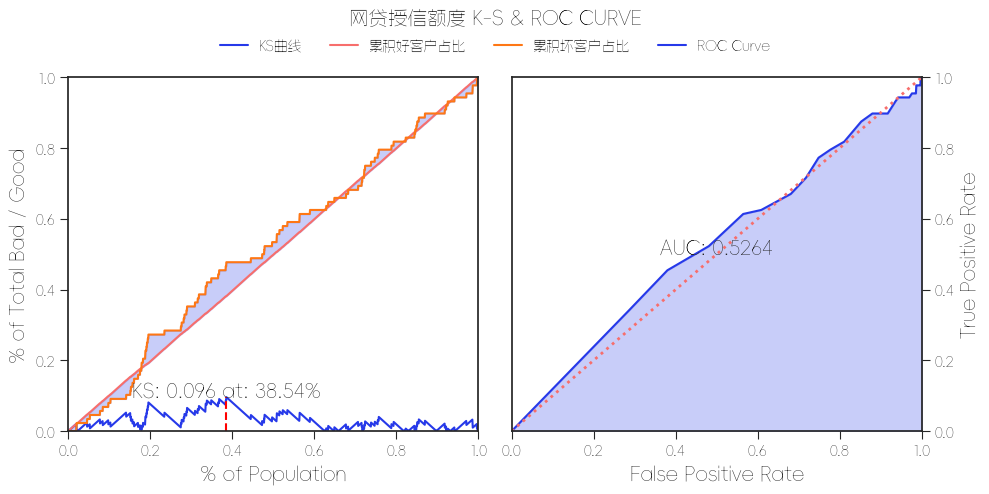

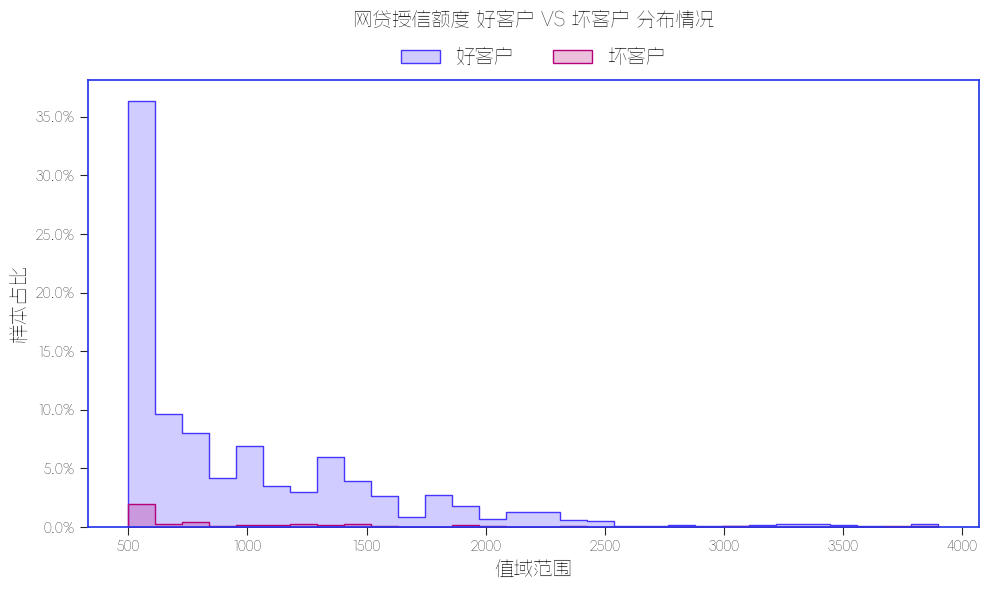

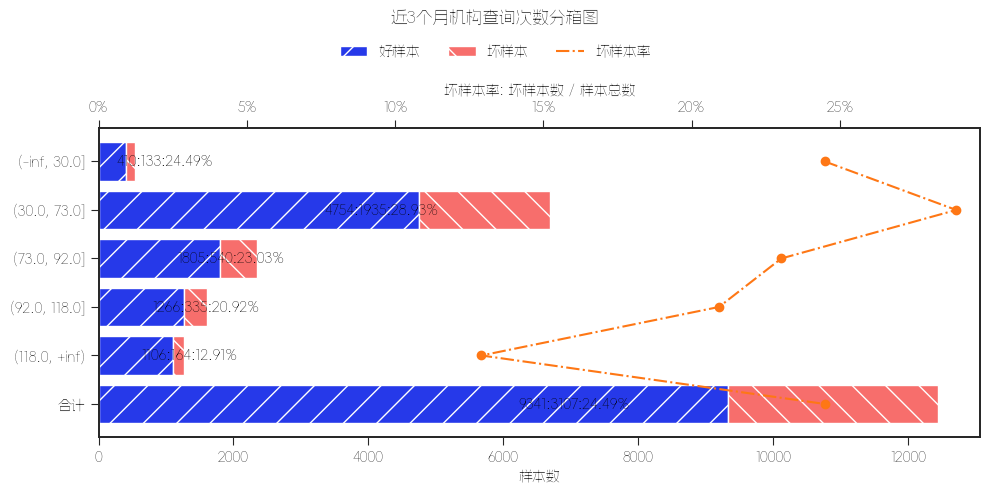

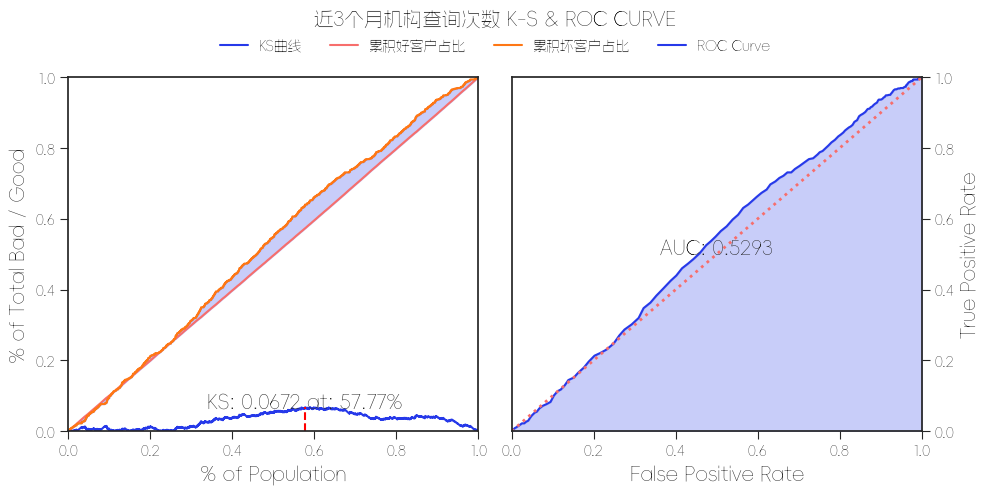

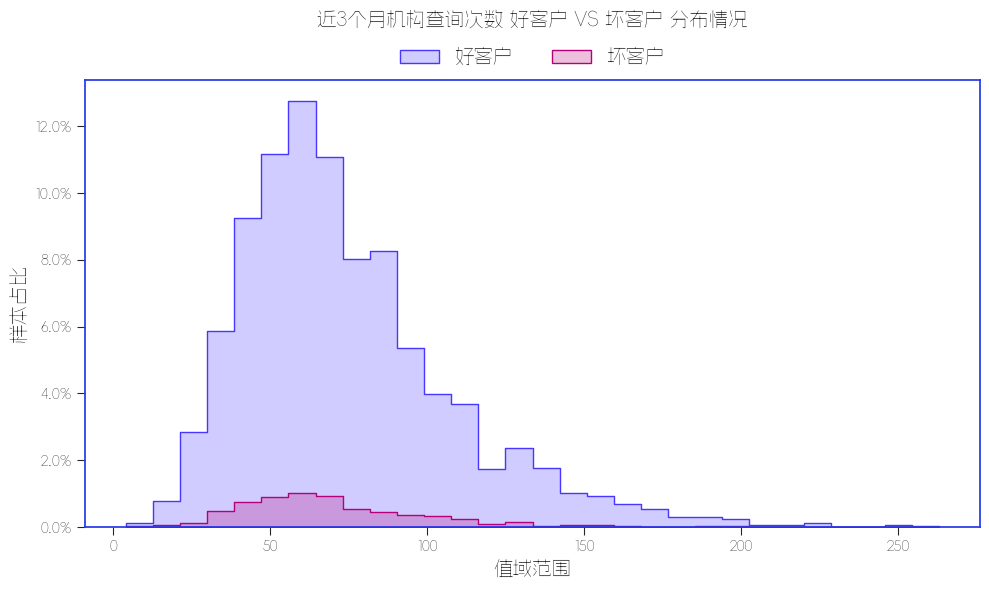

In [13]:
# 生成报告：订单口径 + 金额口径并排展示（中间空一列）
auto_feature_analysis_report(
    data=df,
    features=features,
    overdue=["MOB1", "MOB2"],
    dpds=[15, 7, 0],
    date='loan_date',
    excel_writer='feature_analysis_report_demo.xlsx',
    sheet='分析报告',
    data_summary_comment='hscredit.xlsx 示例（订单口径+金额口径）',
    bin_params=bin_params,
    feature_map=feature_map,
    pictures=['bin', 'ks', 'hist'],
    margins=True,
    amount="loan_amount_demo",
    suffix='_demo',
    # bin_params={"return_cols": ["样本总数", '样本占比', '坏样本率', 'LIFT值', '坏账改善']},
    output_dir='model_report_demo'
)

print('报告已生成:', report_path)
